
# Tata iQ – GenAI Powered Data Analytics Job Simulation

## End-to-End Analysis Notebook

This notebook covers:

- Task 1: Exploratory Data Analysis (EDA) & Risk Profiling
- Task 2: Predictive Modeling Approach
- Task 3: Business Insights & Recommendation Framework

The notebook is designed to align with the Tata iQ simulation requirements and includes explanatory markdown, commented code, visualizations, model development, and business recommendations.


## Import Libraries

In [1]:

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## Load Dataset

In [2]:

# Load dataset
df = pd.read_csv('Delinquency_prediction_dataset.csv')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (500, 19)


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


## Dataset Overview

In [3]:

# Dataset information
df.info()

# Statistical summary
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
count,500,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500,500.000000,500,500,500,500,500,500,500,500
unique,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,5,5,3,3,3,3,3,3
top,CUST0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unemployed,NaN,Gold,Los Angeles,On-time,Late,Late,Late,Missed,Late
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93,NaN,118,107,177,173,169,181,187,172
mean,NaN,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,NaN,9.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,NaN,5.923054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Check Duplicates

In [4]:

# Check duplicate rows
print("Duplicate Records:", df.duplicated().sum())


Duplicate Records: 0


## Missing Value Analysis

In [5]:

# Missing value summary
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round(df.isnull().sum()/len(df)*100,2)
})

missing_df[missing_df['Missing Count'] > 0].sort_values(
    by='Missing Count',
    ascending=False
)


,Missing Count,Missing Percentage
Income,39,7.8
Loan_Balance,29,5.8
Credit_Score,2,0.4


## Visualize Missing Values

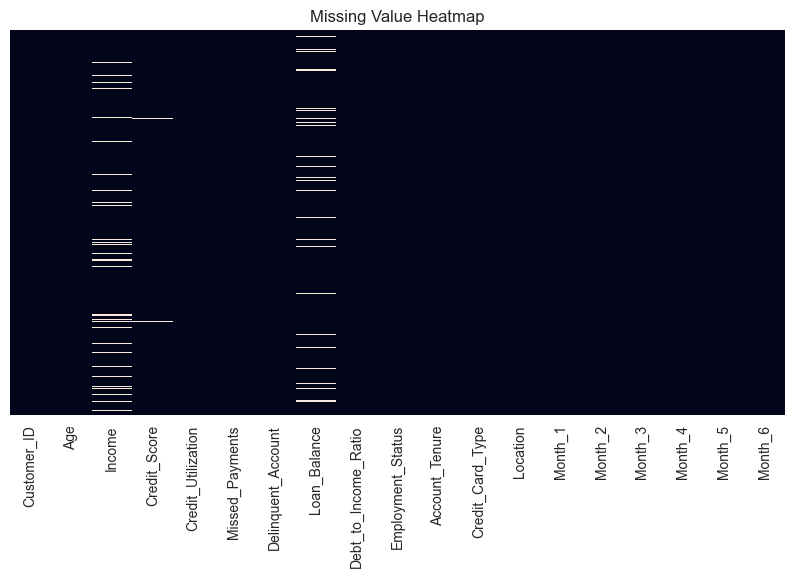

In [6]:

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()


## Employment Status Review

In [7]:

# Check inconsistent labels
df['Employment_Status'].value_counts()


Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64

## Standardize Employment Labels

In [8]:

# Standardize categories
df['Employment_Status'] = df['Employment_Status'].replace({
    'EMP':'Employed',
    'employed':'Employed',
    'retired': 'Retired'
})

df['Employment_Status'].value_counts()


Employment_Status
Employed         240
Unemployed        93
Retired           87
Self-employed     80
Name: count, dtype: int64

## Credit Utilization Quality Check

In [9]:

# Values above logical threshold
df[df['Credit_Utilization'] > 1]


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
89,CUST0090,65,127856.0,361.0,1.025843,2,0,2200.0,0.346267,Employed,14,Standard,Chicago,On-time,Late,On-time,Missed,Missed,On-time
265,CUST0266,72,16062.0,584.0,1.025017,1,0,92285.0,0.240017,Unemployed,17,Gold,Phoenix,Missed,Late,Missed,Missed,On-time,Late
292,CUST0293,49,38061.0,316.0,1.002482,1,0,95267.0,0.448824,Employed,16,Student,Chicago,Late,Late,Late,Late,Missed,Missed
426,CUST0427,49,163216.0,768.0,1.008734,6,0,60530.0,0.452937,Employed,15,Gold,New York,Late,On-time,Missed,Late,Late,Missed


## Missing Value Treatment

In [10]:

# Median imputation for skewed financial variables
median_cols = ['Income','Loan_Balance']

median_imputer = SimpleImputer(strategy='median')
df[median_cols] = median_imputer.fit_transform(df[median_cols])

# Mean imputation for Credit Score
mean_imputer = SimpleImputer(strategy='mean')
df['Credit_Score'] = mean_imputer.fit_transform(df[['Credit_Score']])

# Cap utilization at 100%
df['Credit_Utilization'] = np.where(
    df['Credit_Utilization'] > 1,
    1,
    df['Credit_Utilization']
)

df.isnull().sum()


Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

## Target Variable Distribution

Delinquent_Account
0    420
1     80
Name: count, dtype: int64


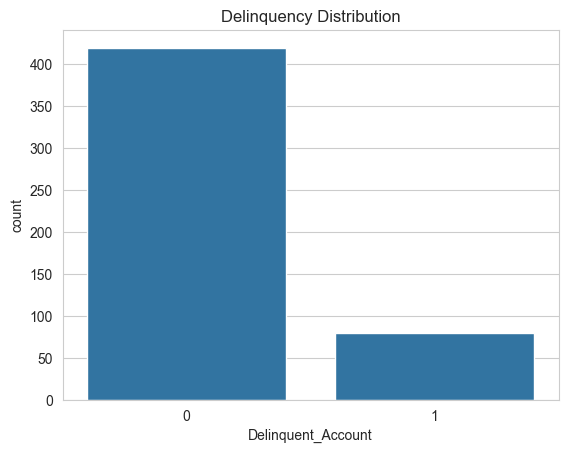

In [11]:

print(df['Delinquent_Account'].value_counts())

sns.countplot(x='Delinquent_Account', data=df)
plt.title('Delinquency Distribution')
plt.show()


## Numerical Feature Distributions

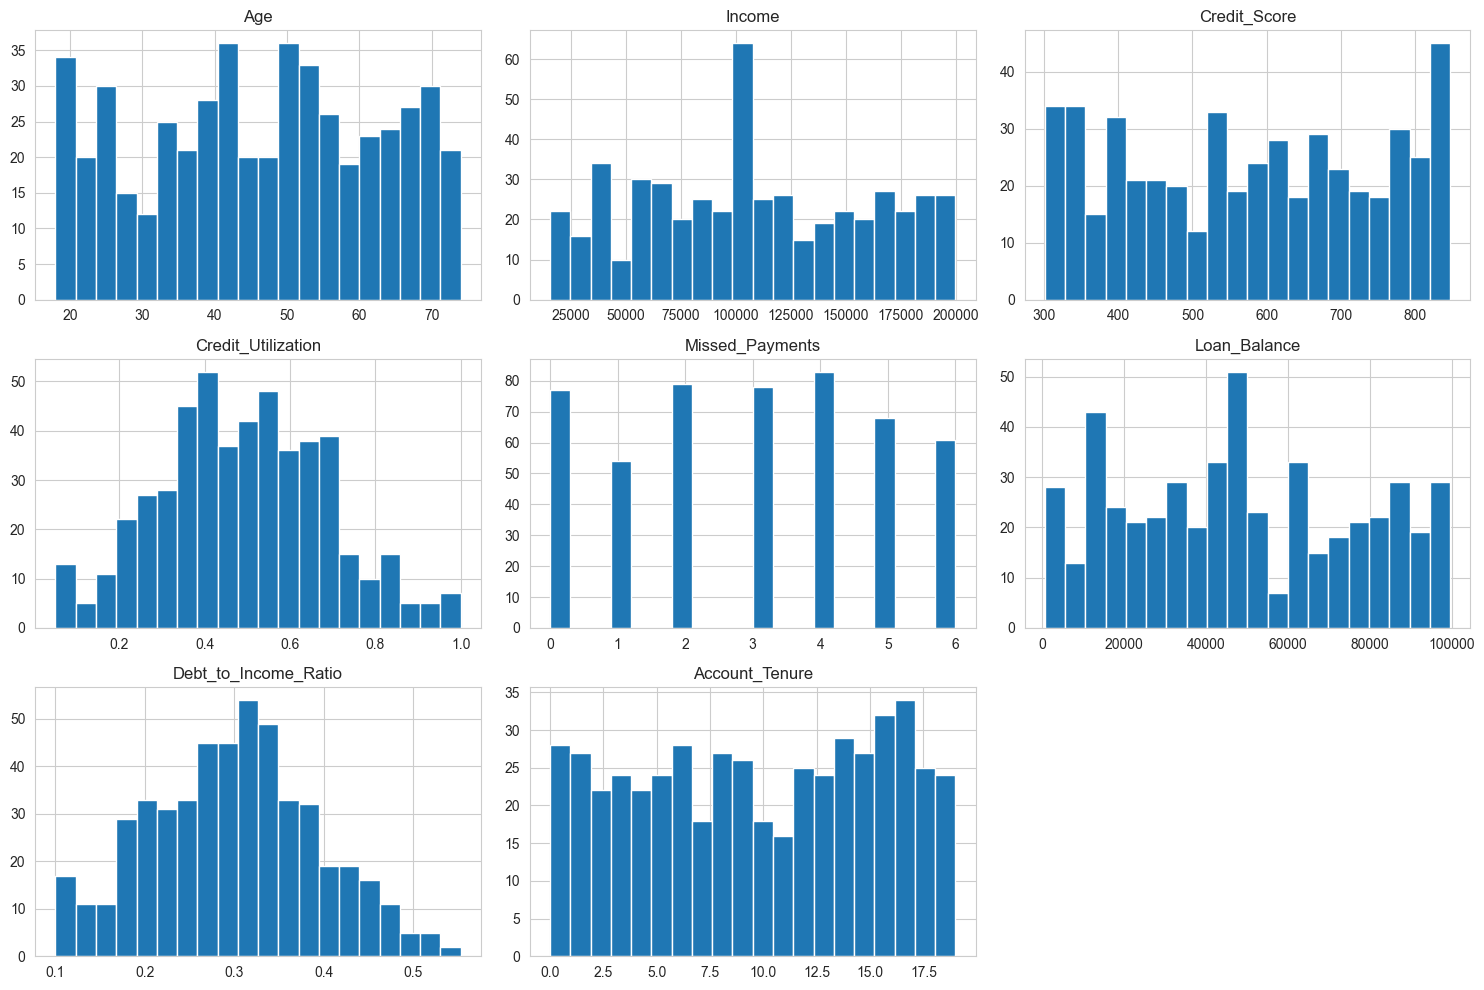

In [12]:

numeric_cols = [
    'Age',
    'Income',
    'Credit_Score',
    'Credit_Utilization',
    'Missed_Payments',
    'Loan_Balance',
    'Debt_to_Income_Ratio',
    'Account_Tenure'
]

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()


## Risk Indicator Analysis

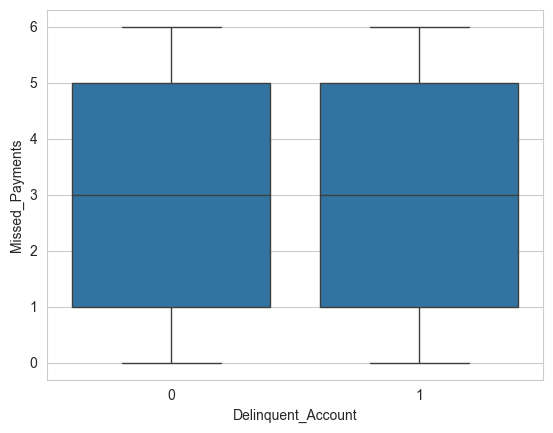

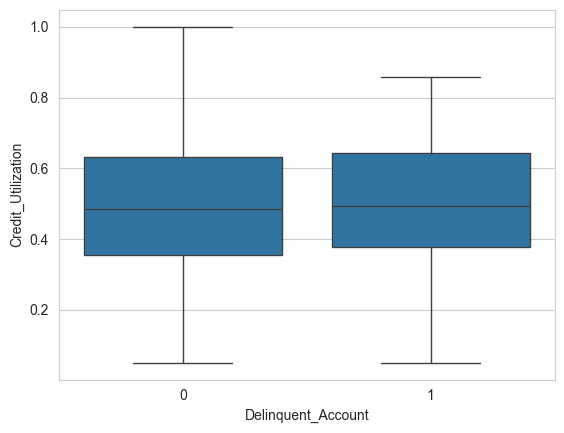

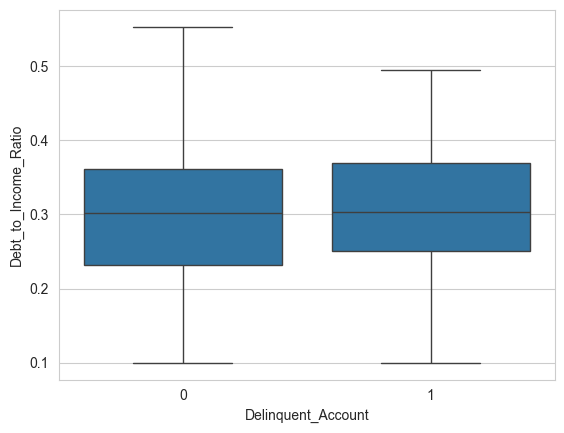

In [13]:

# Missed Payments
sns.boxplot(x='Delinquent_Account',
            y='Missed_Payments',
            data=df)
plt.show()

# Credit Utilization
sns.boxplot(x='Delinquent_Account',
            y='Credit_Utilization',
            data=df)
plt.show()

# Debt to Income Ratio
sns.boxplot(x='Delinquent_Account',
            y='Debt_to_Income_Ratio',
            data=df)
plt.show()


## Employment Risk Analysis

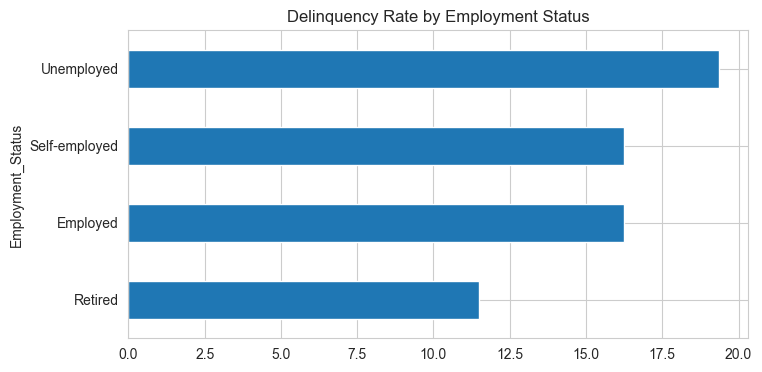

In [14]:

employment_risk = pd.crosstab(
    df['Employment_Status'],
    df['Delinquent_Account'],
    normalize='index'
)*100

employment_risk

employment_risk[1].sort_values().plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Delinquency Rate by Employment Status')
plt.show()


## Credit Card Type Risk Analysis

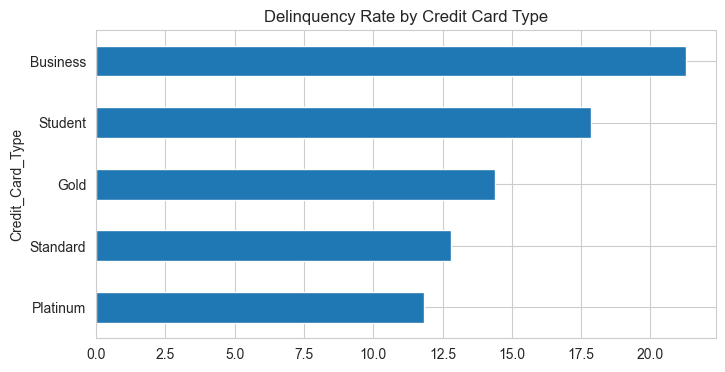

In [15]:

card_risk = pd.crosstab(
    df['Credit_Card_Type'],
    df['Delinquent_Account'],
    normalize='index'
)*100

card_risk

card_risk[1].sort_values().plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Delinquency Rate by Credit Card Type')
plt.show()


## Location Risk Analysis

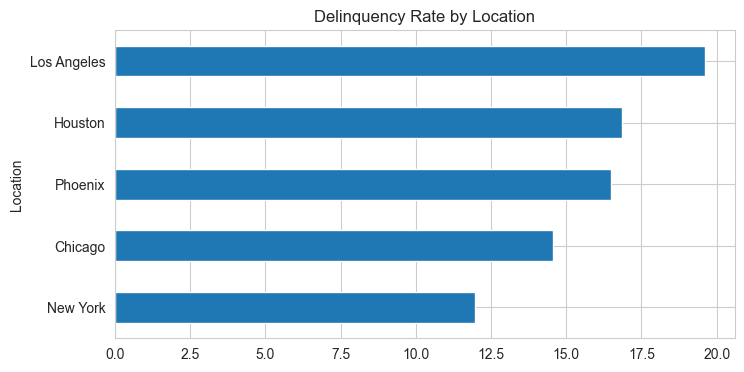

In [16]:

location_risk = pd.crosstab(
    df['Location'],
    df['Delinquent_Account'],
    normalize='index'
)*100

location_risk

location_risk[1].sort_values().plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Delinquency Rate by Location')
plt.show()


## Correlation Analysis

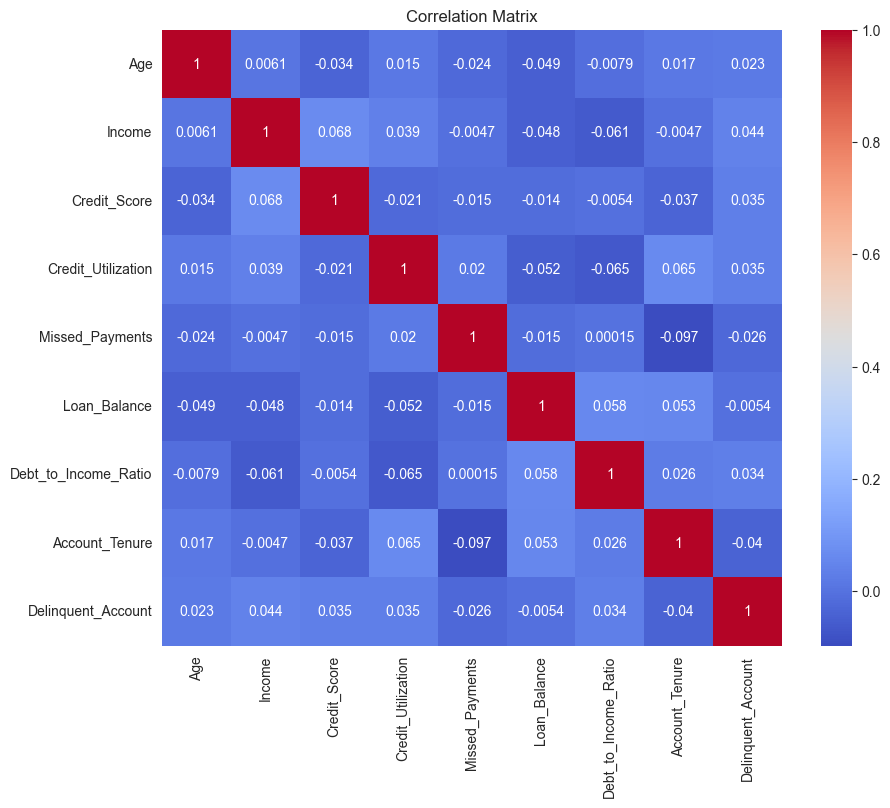

In [17]:

corr = df[numeric_cols + ['Delinquent_Account']].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()



# Task 2 – Predictive Modeling

Logistic Regression is used as a baseline model because it is:
- Interpretable
- Fast to train
- Commonly used in credit-risk prediction
- Easy to explain to business stakeholders


## Data Preparation for Modeling (Feature Engineering)

In [18]:
model_df = df.copy()

# Preserve ordinal meaning for payment history
payment_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']

payment_mapping = {
    'On-time':0,
    'Late':1,
    'Missed':2
}

for col in payment_cols:
    if model_df[col].dtype == 'object':
        model_df[col] = model_df[col].map(payment_mapping)

# One-hot encode nominal categorical features
model_df = pd.get_dummies(
    model_df,
    columns=[
        'Employment_Status',
        'Credit_Card_Type',
        'Location'
    ],
    drop_first=True
)

X = model_df.drop(columns=['Customer_ID','Delinquent_Account'])
y = model_df['Delinquent_Account']

print(X.shape)


(500, 25)


## Train Test Split & Scaling

In [19]:

# Initialize scaler
scaler = StandardScaler()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

# Scale features for Logistic Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


(400, 25)
(100, 25)


## Model Evaluation

In [20]:
lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

preds = lr.predict(X_test_scaled)
probs = lr.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', accuracy_score(y_test, preds))
print('Precision:', precision_score(y_test, preds, zero_division=0))
print('Recall:', recall_score(y_test, preds, zero_division=0))
print('F1:', f1_score(y_test, preds, zero_division=0))
print('ROC AUC:', roc_auc_score(y_test, probs))

print(classification_report(y_test, preds))


Accuracy: 0.46
Precision: 0.1346153846153846
Recall: 0.4375
F1: 0.20588235294117646
ROC AUC: 0.4285714285714286
              precision    recall  f1-score   support

           0       0.81      0.46      0.59        84
           1       0.13      0.44      0.21        16

    accuracy                           0.46       100
   macro avg       0.47      0.45      0.40       100
weighted avg       0.70      0.46      0.53       100



## Confusion Matrix

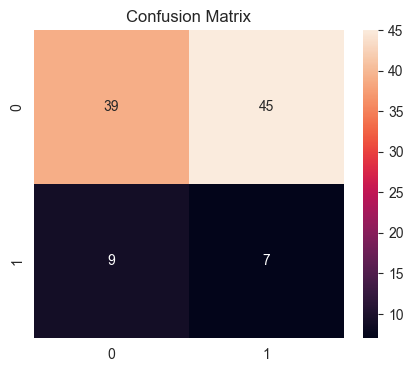

In [21]:

cm = confusion_matrix(y_test,preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()


## Model Interpretation

,Feature,Coefficient
1,Income,0.243839
6,Debt_to_Income_Ratio,0.128003
11,Month_4,0.127844
3,Credit_Utilization,0.118607
0,Age,0.110748
22,Location_Los Angeles,0.098015
21,Location_Houston,0.092873
2,Credit_Score,0.062735
24,Location_Phoenix,0.036066
16,Employment_Status_Unemployed,0.019288


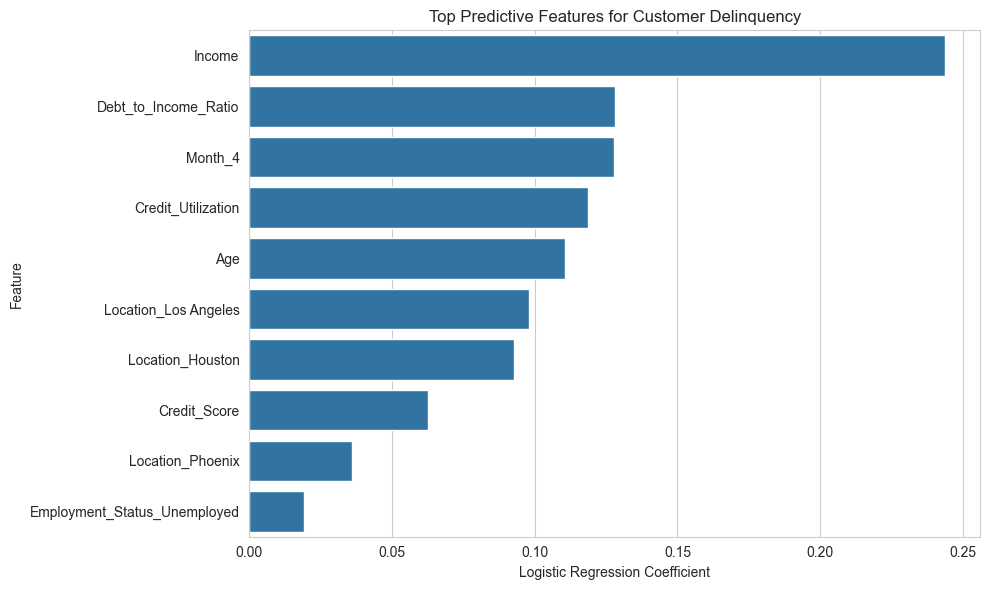

In [22]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Display top 10 features
display(feature_importance.head(10))

# Visualize top features
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Top Predictive Features for Customer Delinquency')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')

plt.tight_layout()

plt.show()


## Top Predictors Visualization

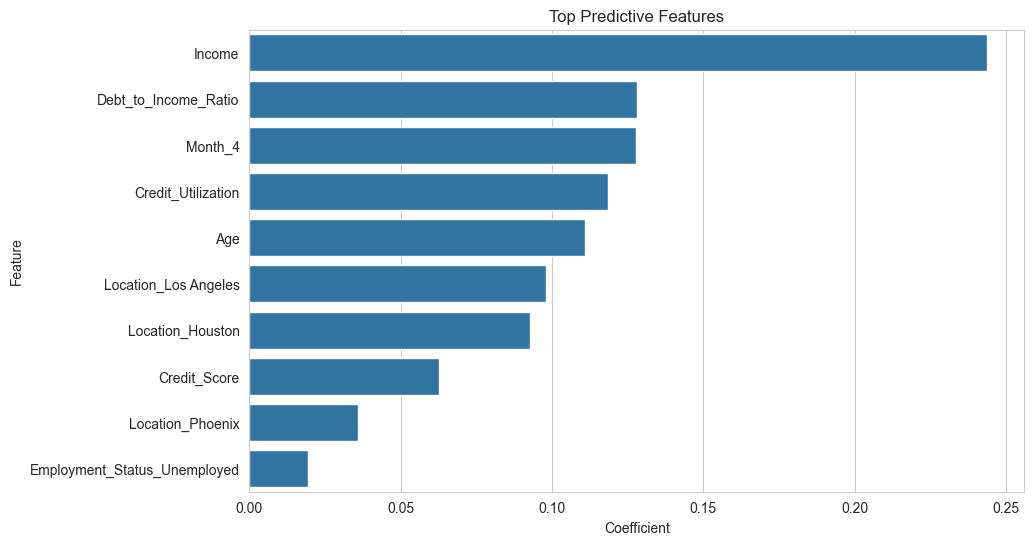

In [23]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top Predictive Features')
plt.show()



# Task 3 – Business Recommendations

Translate analytical findings into actionable recommendations for the Head of Collections.


## Top Risk Factors

In [24]:

top_risk_factors = feature_importance.head(5)

top_risk_factors


,Feature,Coefficient
1,Income,0.243839
6,Debt_to_Income_Ratio,0.128003
11,Month_4,0.127844
3,Credit_Utilization,0.118607
0,Age,0.110748


## Recommendation Framework

In [25]:

print('''

HIGH RISK
- Collections Call
- Repayment Plan
- Early Intervention Strategy

MEDIUM RISK
- SMS / Email Reminder
- Incentive-Based Repayment

LOW RISK
- Routine Monitoring

''')




HIGH RISK
- Collections Call
- Repayment Plan
- Early Intervention Strategy

MEDIUM RISK
- SMS / Email Reminder
- Incentive-Based Repayment

LOW RISK
- Routine Monitoring




## Ethical AI Considerations

In [26]:

print('''

Fairness Risk 1: 
The model may unintentionally favor or disadvantage certain customer groups based on historical data patterns.

Mitigation: 
Regularly monitor model performance across customer segments and conduct fairness audits.

Fairness Risk 2: 
Over-reliance on AI predictions may lead to incorrect collection decisions.

Mitigation: 
Use AI as a decision-support tool and maintain human review for high-risk cases.

Responsible AI: 
Ensure predictions are transparent, explainable, and continuously monitored to support fair and accurate decision-making.

''')




Fairness Risk 1: 
The model may unintentionally favor or disadvantage certain customer groups based on historical data patterns.

Mitigation: 
Regularly monitor model performance across customer segments and conduct fairness audits.

Fairness Risk 2: 
Over-reliance on AI predictions may lead to incorrect collection decisions.

Mitigation: 
Use AI as a decision-support tool and maintain human review for high-risk cases.

Responsible AI: 
Ensure predictions are transparent, explainable, and continuously monitored to support fair and accurate decision-making.




## Model Limitations
- The dataset exhibits class imbalance and limited predictive signal (more non-delinquent than delinquent customers).
- Predictive signal appears limited, resulting in modest model performance.
- Logistic Regression was selected because it is interpretable and widely used in financial risk settings.
- Future improvements may include SMOTE, gradient boosting, and additional feature engineering.